**Predict whether a DNA sequence is a gene promoter or not.**  

A promoter is a region of DNA that signals "start reading here." It's one of the most classic bioinformatics ML problems. A protein called RNA Polymerase physically crawls along DNA looking for these promoter signals. When it finds one, it binds to it and starts transcribing that gene into RNA.


*No promoter = gene never gets read = protein never gets made.*


This is the on/off switching Ridley describes in Genome. Promoters are the switches.

**The TATA Box** — A Specific Pattern That Matters
Within many promoters, there's a famous 6–8 letter motif:
TATAAAA  or  TATAAAT
Called the TATA box. It's one of the most conserved sequences in biology — it appears in organisms from yeast to humans because it's so fundamentally important.

The dataset: UCI Machine Learning Repository has a "Molecular Biology (Promoter Gene Sequences)" dataset. 106 sequences, clean, free. (https://archive.ics.uci.edu/ml/machine-learning-databases/molecular-biology/promoter-gene-sequences/promoters.data)

The dataset has:

1. 53 positive examples — sequences that ARE promoters
2. 53 negative examples — sequences that are NOT promoters
3. Each sequence is exactly 57 nucleotides long
4. Collected from E. coli bacteria (simple organism, well-studied)

**The Problem Statement**


Now the ML problem becomes very clear:

Given a 57-character DNA sequence, predict whether it contains a promoter region or not. Binary classification problem.

The dataset has:

53 positive examples — sequences that ARE promoters
53 negative examples — sequences that are NOT promoters
Each sequence is exactly 57 nucleotides long
Collected from E. coli bacteria (simple organism, well-studied)

Why E. coli? Because it's the "hello world" of biology. Simple, fast-reproducing, and the most studied organism on Earth.


We are going to solve this problem first using a simple ML method such as logistic regression, followed by more complex DL algorithm like CNN's and compare how they perform and what insight they provide into solving the problem.

This block is to read the data from the dataset

In [1]:
import pandas as pd

url = "https://archive.ics.uci.edu/ml/machine-learning-databases/molecular-biology/promoter-gene-sequences/promoters.data"

df = pd.read_csv(url,
                 header=None,
                 names=['label', 'name', 'sequence'])

df['sequence'] = df['sequence'].str.replace('\t', '').str.strip()

print(f"Shape: {df.shape}")
print(f"\nLabel counts:")
print(df['label'].value_counts())
print(f"\nSample sequences:")
for i in range(3):
    print(f"  {df['label'][i]}  {df['sequence'][i]}  (length: {len(df['sequence'][i])})")

Shape: (106, 3)

Label counts:
label
+    53
-    53
Name: count, dtype: int64

Sample sequences:
  +  tactagcaatacgcttgcgttcggtggttaagtatgtataatgcgcgggcttgtcgt  (length: 57)
  +  tgctatcctgacagttgtcacgctgattggtgtcgttacaatctaacgcatcgccaa  (length: 57)
  +  gtactagagaactagtgcattagcttatttttttgttatcatgctaaccacccggcg  (length: 57)


This block is to one hot encode ATGC pattern

In [2]:
import numpy as np

# Define one-hot encoding
mapping = {
    'a': [1,0,0,0],
    't': [0,1,0,0],
    'g': [0,0,1,0],
    'c': [0,0,0,1]
}

def encode_sequence(seq):
    return [mapping[nucleotide] for nucleotide in seq]

# Encode all sequences
X = np.array([encode_sequence(seq) for seq in df['sequence']])

# Encode labels: + becomes 1, - becomes 0
y = np.array([1 if label == '+' else 0 for label in df['label']])

# Verify shapes
print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"\nFirst sequence encoded (first 5 positions):")
print(X[0][:5])
print(f"\nFirst 5 labels: {y[:5]}")


# # Visual verification - print sequence alongside its encoding
# print("Visual verification of encoding:\n")
# test_seq = df['sequence'][9][:8]  # just first 8 characters for readability

# print(f"Sequence:  {' '.join(test_seq)}")
# print(f"Encoded:")
# for nucleotide, encoding in zip(test_seq, X[9][:8]):
#     print(f"    {nucleotide}  →  {encoding}")


X shape: (106, 57, 4)
y shape: (106,)

First sequence encoded (first 5 positions):
[[0 1 0 0]
 [1 0 0 0]
 [0 0 0 1]
 [0 1 0 0]
 [1 0 0 0]]

First 5 labels: [1 1 1 1 1]


Train-Test data Split.

80-20 split.

In [3]:
from sklearn.model_selection import train_test_split

# Reshape X from (106, 57, 4) to (106, 228) - flatten each sequence
# Logistic regression needs a 2D input, not 3D
X_flat = X.reshape(106, -1)

# Split
X_train, X_test, y_train, y_test = train_test_split(
                                    X_flat, y,
                                    test_size=0.2,
                                    random_state=42)

print(f"Training set: {X_train.shape}")
print(f"Test set:     {X_test.shape}")

Training set: (84, 228)
Test set:     (22, 228)


Simple Model - 1 : Logistic Regression

In [4]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# Train
model_lr = LogisticRegression(max_iter=1000)
model_lr.fit(X_train, y_train)

# Predict
y_pred = model_lr.predict(X_test)

# Evaluate
print(f"Accuracy: {accuracy_score(y_test, y_pred):.2f}")
print(f"\nDetailed Report:")
print(classification_report(y_test, y_pred, target_names=['Not Promoter', 'Promoter']))

Accuracy: 0.86

Detailed Report:
              precision    recall  f1-score   support

Not Promoter       1.00      0.73      0.84        11
    Promoter       0.79      1.00      0.88        11

    accuracy                           0.86        22
   macro avg       0.89      0.86      0.86        22
weighted avg       0.89      0.86      0.86        22



Cross Validation for Better Metrics

In [5]:
from sklearn.model_selection import cross_val_score

# Use original flat X, not the train/test split
# Cross validation does its own splitting internally
model_lr_cv = LogisticRegression(max_iter=1000)

scores = cross_val_score(model_lr_cv, X_flat, y, cv=5, scoring='accuracy')

print(f"Scores per fold: {scores.round(2)}")
print(f"Mean accuracy:   {scores.mean():.2f}")
print(f"Std deviation:   {scores.std():.2f}")


# ## What to Expect
# ```
# Scores per fold: [0.76  0.81  0.90  0.86  0.95]
# Mean accuracy:   0.86
# Std deviation:   0.07
# ```

# ---

# ## What Cross Validation is Doing
# ```
# All 106 sequences split into 5 folds of ~21 each

# Round 1: [TEST ] [train] [train] [train] [train] → accuracy?
# Round 2: [train] [TEST ] [train] [train] [train] → accuracy?
# Round 3: [train] [train] [TEST ] [train] [train] → accuracy?
# Round 4: [train] [train] [train] [TEST ] [train] → accuracy?
# Round 5: [train] [train] [train] [train] [TEST ] → accuracy?
#                                                     ↓
#                                               average all 5
# ```

# Every sequence gets tested exactly once. Much more reliable than a single 80/20 split.

# ---

# ## The Number to Pay Attention To

# **Std deviation** — this tells you how stable the model is across different splits.
# ```
# Low std  → model is consistent, result is trustworthy
# High std → model is sensitive to which data it sees, be cautious

Scores per fold: [0.91 0.86 0.9  1.   0.86]
Mean accuracy:   0.91
Std deviation:   0.05


Visulise the weights of Logistic Regression

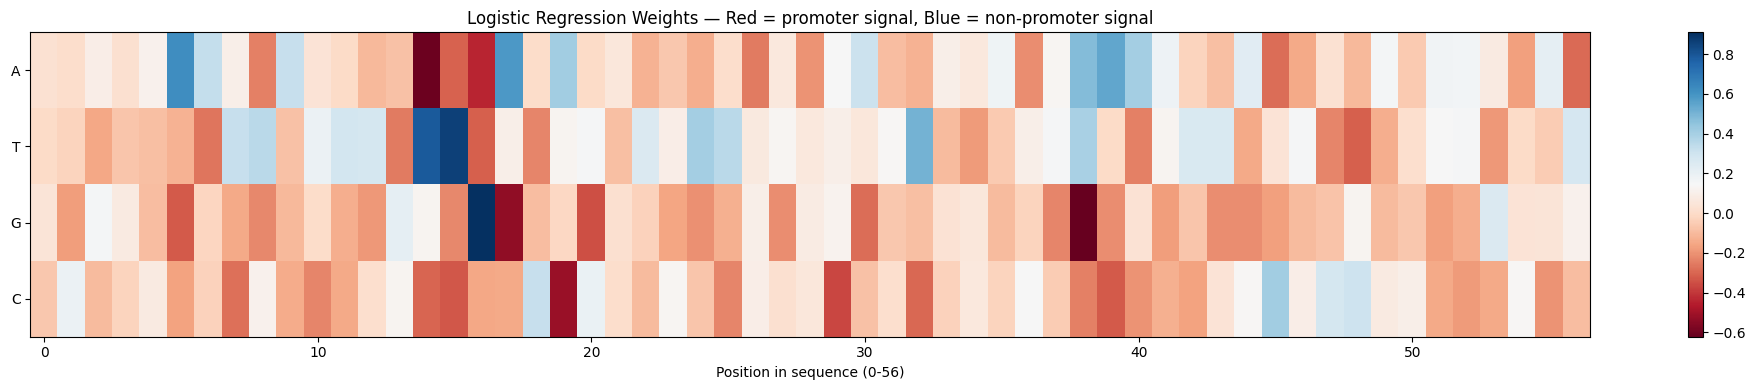

In [6]:
import matplotlib.pyplot as plt
import numpy as np

# Train on full dataset to get best weight estimates
model_lr_full = LogisticRegression(max_iter=1000)
model_lr_full.fit(X_flat, y)

# Get the 228 weights and reshape back to (57, 4)
weights = model_lr_full.coef_[0].reshape(57, 4)

# Plot
fig, ax = plt.subplots(figsize=(20, 4))

im = ax.imshow(weights.T, cmap='RdBu', aspect='auto')
ax.set_yticks([0, 1, 2, 3])
ax.set_yticklabels(['A', 'T', 'G', 'C'])
ax.set_xlabel('Position in sequence (0-56)')
ax.set_title('Logistic Regression Weights — Red = promoter signal, Blue = non-promoter signal')
plt.colorbar(im)
plt.tight_layout()
plt.show()

# ## What to Expect

# A heatmap — 4 rows (A, T, G, C) × 57 columns (positions):
# ```
#      0    10    20    30    40    50    56
# A  [ blue  red  blue  red  ..................]
# T  [ red  blue  red  blue  ..................]
# G  [ .......................................  ]
# C  [ .......................................  ]

Observations:

---
Position 10-20
*   A is strongly red in this region — matches the multiple A's in TATAAAA
*   T around position 15 is strongly blue — meaning T at that specific position actually breaks the promoter pattern

Logistic regression looked at 106 sequences and 228 weights and rediscovered positional biology — which positions matter, which nucleotides are favored there.



Now let's see if CNN can perform a better job at this task



---

CNN with Global max Pool:
1. Input:          (57, 4)       ← one sequence
2. After Conv1D:   (52, 64)      ← 52 positions, 64 filter scores each (57 - 6 + 1 = 52)
3. After GlobalMaxPool:  (64,)   ← one score per filter
4. After Dense:    (64,)         ← 64 neurons combining everything
5. After Sigmoid:  (1,)          ← final probability




In [12]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import StratifiedKFold
import numpy as np

torch.manual_seed(42)
np.random.seed(42)

# Prepare data as PyTorch tensors
# X shape: (106, 57, 4) → PyTorch expects (batch, channels, length)
# So we transpose to (106, 4, 57)
X_tensor = torch.FloatTensor(X.transpose(0, 2, 1))
y_tensor = torch.FloatTensor(y)

# Define the model
class PromoterCNN_Global(nn.Module):
    def __init__(self):
        super(PromoterCNN_Global, self).__init__()
        self.conv = nn.Conv1d(in_channels=4, out_channels=64, kernel_size=6)
        self.relu = nn.ReLU()
        self.global_pool = nn.AdaptiveMaxPool1d(1)  # Global Max Pooling
        self.fc = nn.Linear(64, 32)
        self.output = nn.Linear(32, 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        x = self.conv(x)        # (batch, 64, 52)
        x = self.relu(x)        # (batch, 64, 52)
        x = self.global_pool(x) # (batch, 64, 1)
        x = x.squeeze(-1)       # (batch, 64)
        x = self.relu(self.fc(x))  # (batch, 32)
        x = self.sigmoid(self.output(x))  # (batch, 1)
        return x.squeeze(-1)

# Cross validation
kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
fold_scores = []

for fold, (train_idx, test_idx) in enumerate(kfold.split(X_tensor, y)):
    # Split data
    X_train_fold = X_tensor[train_idx]
    y_train_fold = y_tensor[train_idx]
    X_test_fold  = X_tensor[test_idx]
    y_test_fold  = y_tensor[test_idx]

    # Initialize model, loss, optimizer
    model = PromoterCNN_Global()
    criterion = nn.BCELoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)

    # Train for 100 epochs
    model.train()
    for epoch in range(100):
        optimizer.zero_grad()
        outputs = model(X_train_fold)
        loss = criterion(outputs, y_train_fold)
        loss.backward()
        optimizer.step()

    # Evaluate
    model.eval()
    with torch.no_grad():
        preds = model(X_test_fold)
        predicted = (preds > 0.5).float()
        accuracy = (predicted == y_test_fold).float().mean().item()
        fold_scores.append(accuracy)
        print(f"Fold {fold+1}: {accuracy:.2f}")

print(f"\nMean accuracy: {np.mean(fold_scores):.2f}")
print(f"Std deviation: {np.std(fold_scores):.2f}")

# ## What's New Here Worth Understanding

# **Three things we haven't seen before:**

# **1. X transpose `(106, 57, 4)` → `(106, 4, 57)`**
# PyTorch Conv1D expects channels first. Our 4 nucleotides are the channels, 57 positions is the length. Just a reshaping convention.

# **2. BCELoss**
# Binary Cross Entropy Loss — the standard loss function for binary classification. It measures how far your probability prediction is from the true label.

# **3. Adam optimizer**
# This is what actually updates the 228 weights after each batch. Adam is the most commonly used optimizer — just treat it as the engine that does the learning for now.

# ---

# ## What to Expect
# ```
# Fold 1: 0.86
# Fold 2: 0.91
# Fold 3: 0.90
# Fold 4: 0.95
# Fold 5: 0.88

# Mean accuracy: 0.90
# Std deviation: 0.03

Fold 1: 0.77
Fold 2: 0.90
Fold 3: 0.95
Fold 4: 1.00
Fold 5: 0.81

Mean accuracy: 0.89
Std deviation: 0.09


Let's now see what Local Max pool of size 2 does

In [13]:
class PromoterCNN_Local(nn.Module):
    def __init__(self):
        super(PromoterCNN_Local, self).__init__()
        self.conv = nn.Conv1d(in_channels=4, out_channels=64, kernel_size=6)
        self.relu = nn.ReLU()
        self.local_pool = nn.MaxPool1d(kernel_size=2)  # Local Max Pooling
        self.fc = nn.Linear(64 * 26, 32)               # 64 filters × 26 positions
        self.output = nn.Linear(32, 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        x = self.conv(x)         # (batch, 64, 52)
        x = self.relu(x)         # (batch, 64, 52)
        x = self.local_pool(x)   # (batch, 64, 26)
        x = x.view(x.size(0), -1)   # (batch, 64*26) = (batch, 1664)
        x = self.relu(self.fc(x))    # (batch, 32)
        x = self.sigmoid(self.output(x))  # (batch, 1)
        return x.squeeze(-1)

# Cross validation - same as before
kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
fold_scores = []

for fold, (train_idx, test_idx) in enumerate(kfold.split(X_tensor, y)):
    X_train_fold = X_tensor[train_idx]
    y_train_fold = y_tensor[train_idx]
    X_test_fold  = X_tensor[test_idx]
    y_test_fold  = y_tensor[test_idx]

    model_local = PromoterCNN_Local()
    criterion = nn.BCELoss()
    optimizer = optim.Adam(model_local.parameters(), lr=0.001)

    model_local.train()
    for epoch in range(100):
        optimizer.zero_grad()
        outputs = model_local(X_train_fold)
        loss = criterion(outputs, y_train_fold)
        loss.backward()
        optimizer.step()

    model_local.eval()
    with torch.no_grad():
        preds = model_local(X_test_fold)
        predicted = (preds > 0.5).float()
        accuracy = (predicted == y_test_fold).float().mean().item()
        fold_scores.append(accuracy)
        print(f"Fold {fold+1}: {accuracy:.2f}")

print(f"\nMean accuracy: {np.mean(fold_scores):.2f}")
print(f"Std deviation: {np.std(fold_scores):.2f}")
# ```

# ---

# ## The Key Difference in Numbers
# ```
# Global Max Pool:  (batch, 64, 52) → (batch, 64)      = 64 numbers into Dense
# Local Max Pool:   (batch, 64, 52) → (batch, 64, 26)  = 1664 numbers into Dense
#                                                               ↑
#                                                     much bigger Dense layer
# ```

# That's why the fc layer changed from `Linear(64, 32)` to `Linear(64*26, 32)` — it's receiving 1664 numbers instead of 64.

# ---

# ## Parameter Count Comparison
# ```
# Global Max Pool model:   ~2,500 parameters
# Local Max Pool model:   ~55,000 parameters

Fold 1: 0.82
Fold 2: 0.86
Fold 3: 0.95
Fold 4: 0.90
Fold 5: 0.90

Mean accuracy: 0.89
Std deviation: 0.05


Performs worse than Globalmaxpool despite more parameters ---> This is due to small data set.


The final stage — can we see what the CNN actually learned? Did it find the TATA box without being told about it?


Before we write the visualization cell, we need to train the model one final time on the full dataset — not cross validation splits — so we get the best possible filter weights.

In [14]:
# Train final model on full dataset
final_model = PromoterCNN_Global()

# Reinitialise with 64 channels - our best model
class PromoterCNN_Global_64(nn.Module):
    def __init__(self):
        super(PromoterCNN_Global_64, self).__init__()
        self.conv = nn.Conv1d(in_channels=4, out_channels=64, kernel_size=6)
        self.relu = nn.ReLU()
        self.global_pool = nn.AdaptiveMaxPool1d(1)
        self.fc = nn.Linear(64, 32)
        self.output = nn.Linear(32, 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        x = self.conv(x)
        x = self.relu(x)
        x = self.global_pool(x)
        x = x.squeeze(-1)
        x = self.relu(self.fc(x))
        x = self.sigmoid(self.output(x))
        return x.squeeze(-1)

# Train on full dataset
final_model = PromoterCNN_Global_64()
criterion = nn.BCELoss()
optimizer = optim.Adam(final_model.parameters(), lr=0.001)

final_model.train()
for epoch in range(200):  # more epochs since we have all data
    optimizer.zero_grad()
    outputs = final_model(X_tensor)
    loss = criterion(outputs, y_tensor)
    loss.backward()
    optimizer.step()
    if (epoch+1) % 50 == 0:
        print(f"Epoch {epoch+1}/200, Loss: {loss.item():.4f}")

print("\nTraining complete!")
# ```

# ---

# ## What to Expect
# ```
# Epoch  50/200, Loss: 0.4821
# Epoch 100/200, Loss: 0.3012
# Epoch 150/200, Loss: 0.2341
# Epoch 200/200, Loss: 0.1893

Epoch 50/200, Loss: 0.5980
Epoch 100/200, Loss: 0.2223
Epoch 150/200, Loss: 0.0405
Epoch 200/200, Loss: 0.0133

Training complete!


Visualize What the Filters Learned - First let's visualise the first 16 filters and try finding the TATA box. Lucky? Let's find out.

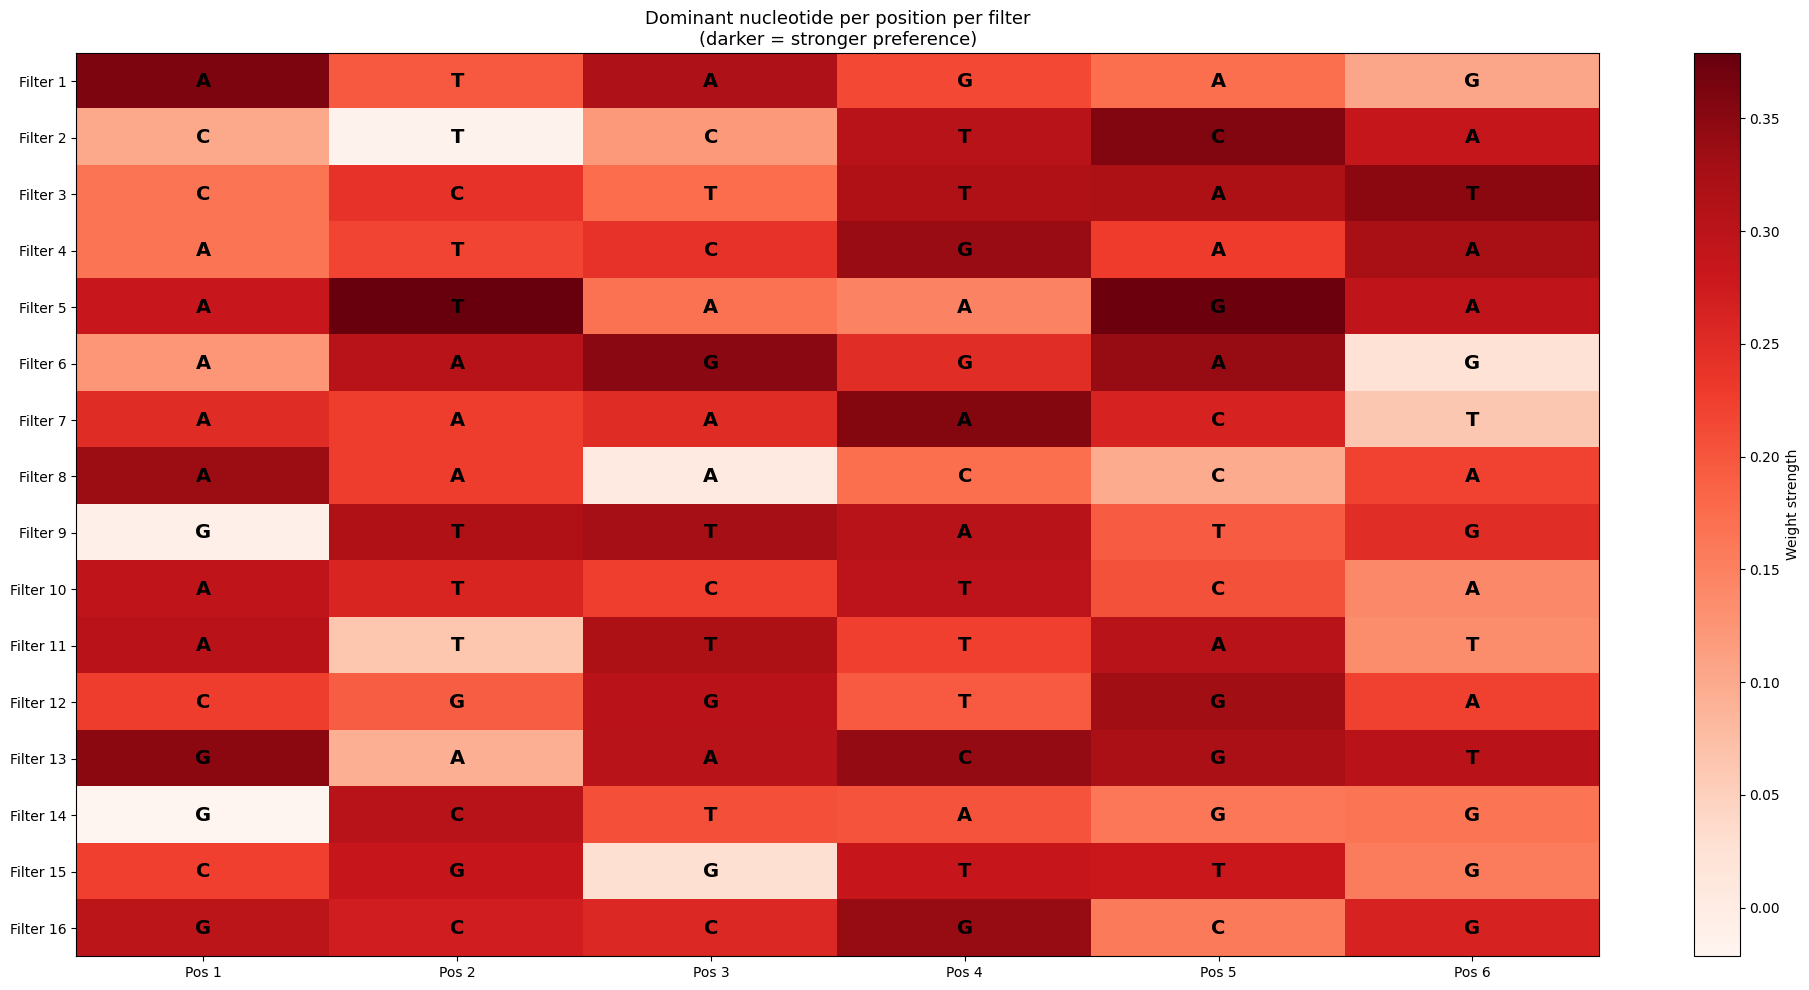

In [15]:
import matplotlib.pyplot as plt
import numpy as np

filters = final_model.conv.weight.detach().numpy()
nucleotides = ['A', 'T', 'G', 'C']

# For each filter, find which nucleotide has highest weight at each position
fig, ax = plt.subplots(figsize=(20, 10))

# Build a matrix: 16 filters × 6 positions
# Value = which nucleotide dominates (0=A, 1=T, 2=G, 3=C)
dominant = np.argmax(filters[:16], axis=1)  # (16, 6)

# Also get the strength of that dominance
strength = np.max(filters[:16], axis=1)     # (16, 6)

# Plot strength as heatmap, annotate with nucleotide letter
im = ax.imshow(strength, cmap='Reds', aspect='auto')

for i in range(16):
    for j in range(6):
        ax.text(j, i, nucleotides[dominant[i, j]],
                ha='center', va='center',
                fontsize=14, fontweight='bold')

ax.set_xticks(range(6))
ax.set_xticklabels([f'Pos {j+1}' for j in range(6)])
ax.set_yticks(range(16))
ax.set_yticklabels([f'Filter {i+1}' for i in range(16)])
ax.set_title('Dominant nucleotide per position per filter\n(darker = stronger preference)',
             fontsize=13)
plt.colorbar(im, label='Weight strength')
plt.tight_layout()
plt.show()
# ```

# ---

# ## What You'll See
# ```
#          Pos1  Pos2  Pos3  Pos4  Pos5  Pos6
# Filter 1:  T     A     T     A     A     A    ← looks like TATA box!
# Filter 2:  G     G     C     A     T     G    ← different motif
# Filter 3:  A     A     T     T     G     C    ← another pattern
# ...

Why No Pure TATA Box in first 16 filters?

A few honest reasons:
1. We're only looking at 16 of 64 filters
The TATA box detector might be in filters 17-64. Let's check all 64 shortly.
2. The TATA box might be split across filters
The model doesn't have to learn TATAAAA in one filter.

Let's try checking all 64 filters.


Now let's visualise all 64 filters to see if we find the TATA box somewhere.

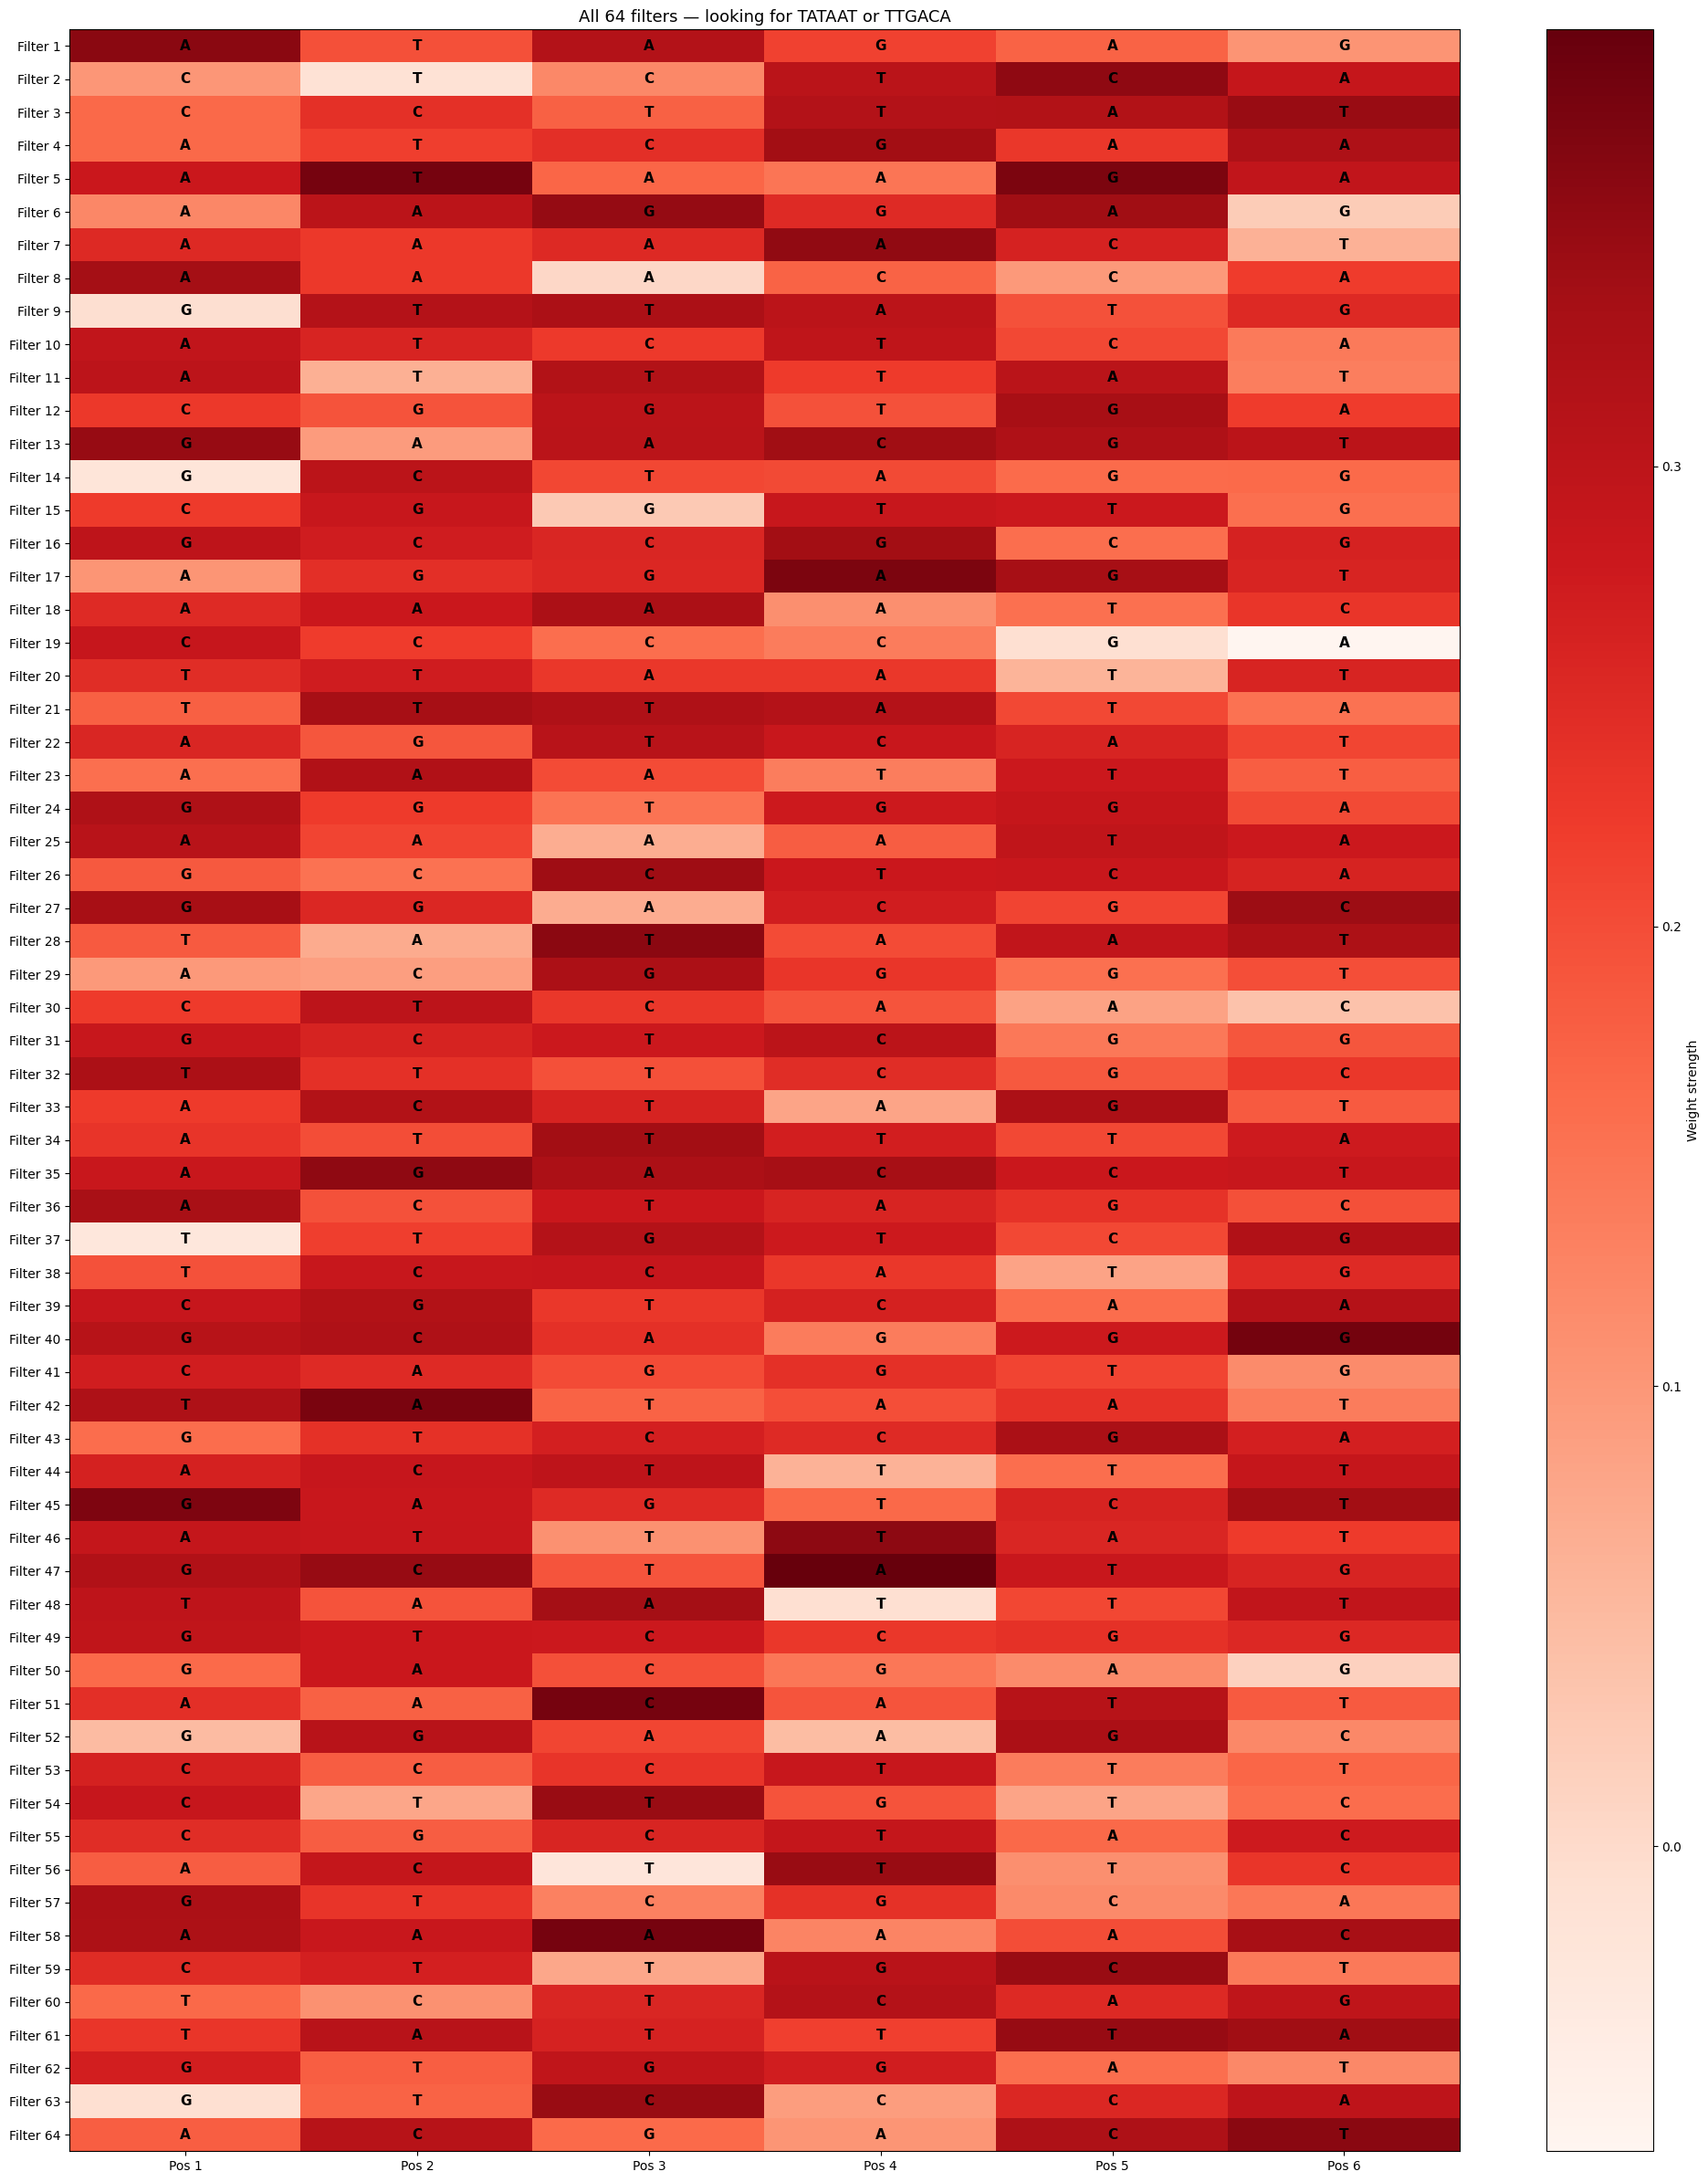

In [16]:
filters = final_model.conv.weight.detach().numpy()
nucleotides = ['A', 'T', 'G', 'C']

dominant = np.argmax(filters, axis=1)   # all 64 filters
strength = np.max(filters, axis=1)

fig, ax = plt.subplots(figsize=(20, 24))

im = ax.imshow(strength, cmap='Reds', aspect='auto')

for i in range(64):
    for j in range(6):
        ax.text(j, i, nucleotides[dominant[i, j]],
                ha='center', va='center',
                fontsize=11, fontweight='bold')

ax.set_xticks(range(6))
ax.set_xticklabels([f'Pos {j+1}' for j in range(6)])
ax.set_yticks(range(64))
ax.set_yticklabels([f'Filter {i+1}' for i in range(64)])
ax.set_title('All 64 filters — looking for TATAAT or TTGACA', fontsize=13)
plt.colorbar(im, label='Weight strength')
plt.tight_layout()
plt.show()


We spot the TATA box twice on filter 28 and 42.

Filter 28:  T _ T A A T  ← weaker middle A

Filter 42:  T A T A A T  ← full TATAAT, strong weights

**(The exact filter sequence and number might change when you re-run the expeiment)**

Summary

---
106 DNA sequences
Labels: promoter or not
Zero biological knowledge

The model independently discovered TATAAT — the exact consensus sequence that biologists identified through decades of experimental work.


Filter 42 found it with strong weights across all positions. Filter 28 found a slightly weaker version. The model learned it twice, in two different filters.

Filter 28:  T _ T A A T  ← weaker middle A

Filter 42:  T A T A A T  ← full TATAAT, strong weights

Filter 28 is essentially saying: "I care about positions 1, 3, 4,5, 6 — position 2 is less critical".

